# 07. Сегментированная регрессия

**Проблема из блока 6**: после WLS гетероскедастичность снижена в 8×, но формально BP всё ещё отвергает. Возможная причина — **разные сегменты с разными «механизмами ценообразования»** смешаны в одной модели.

**Гипотеза**: разделить данные на сегменты, в каждом построить отдельную регрессию. Если внутри сегмента гомоскедастичность лучше — это подтверждает гипотезу.

**Кандидаты сегментации**:
- `vehicle_state`: «на ходу» (11434) vs «битый / не на ходу» (476)
- Возрастные группы: новые (0-7 лет) vs старые (8+)

Сравним обе.


In [1]:
import sys, pathlib, json as _json
sys.path.insert(0, str(pathlib.Path('.').resolve()))
from helpers import (set_plot_style, load_data, impute_median, make_design,
                     backward_elimination, derived_features,
                     NUM_COLS_FULL, CAT_FEATURES)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import durbin_watson

set_plot_style()
df, df_train, df_test = load_data()
df_train = impute_median(df_train, NUM_COLS_FULL)
df_train = derived_features(df_train, center=True)
with open('selected_features.json') as fh:
    KEEP = _json.load(fh)['keep']

fe_num_base = [c for c in KEEP if c not in ('age', 'mileage', 'weight_curb')]
fe_num_base += ['age_c', 'mileage_c', 'ln_weight_curb']
fe_num = fe_num_base + ['hp_per_kg', 'hp_per_liter',
                         'age_c_sq', 'mileage_c_sq', 'ln_mileage',
                         'engine_x_age']


## 1. Сегментация по `vehicle_state`


In [2]:
df_run = df_train[df_train['vehicle_state'] == 'на ходу'].reset_index(drop=True)
df_brk = df_train[df_train['vehicle_state'] == 'битый / не на ходу'].reset_index(drop=True)
print(f'На ходу:  {len(df_run)} наблюдений')
print(f'Битые:    {len(df_brk)} наблюдений')


На ходу:  9096 наблюдений
Битые:    384 наблюдений


In [3]:
def fit_segment(df_sub, label, min_n=50):
    if len(df_sub) < min_n:
        print(f'{label}: выборка слишком мала ({len(df_sub)}<{min_n})')
        return None
    # пересчёт центрирования внутри сегмента (важно)
    df_sub = df_sub.copy()
    df_sub['age_c']        = df_sub['age'] - df_sub['age'].mean()
    df_sub['mileage_c']    = df_sub['mileage'] - df_sub['mileage'].mean()
    df_sub['age_c_sq']     = df_sub['age_c'] ** 2
    df_sub['mileage_c_sq'] = (df_sub['mileage_c'] / 1e5) ** 2
    df_sub['engine_x_age'] = df_sub['engine_volume'] * df_sub['age_c']

    X, _ = make_design(df_sub, fe_num, CAT_FEATURES)
    X_c = sm.add_constant(X.astype(float))
    y = df_sub['price_log1p'].values
    m = sm.OLS(y, X_c).fit()
    m_back, X_back, _ = backward_elimination(X_c, y, alpha=0.05)
    bp = het_breuschpagan(m_back.resid, X_back)
    return {'model': m_back, 'X': X_back, 'y': y, 'bp_lm': bp[0], 'bp_p': bp[1],
            'n': len(df_sub), 'label': label}

seg_run = fit_segment(df_run, 'на ходу')
seg_brk = fit_segment(df_brk, 'битые')

for s in (seg_run, seg_brk):
    if s is None: continue
    m = s['model']
    print(f'[{s["label"]}]  n={s["n"]}  R²adj={m.rsquared_adj:.4f}  '
          f'AIC={m.aic:.0f}  BIC={m.bic:.0f}  k={len(m.params)}')
    print(f'              BP LM={s["bp_lm"]:.0f}  p={s["bp_p"]:.3g}')


[на ходу]  n=9096  R²adj=0.8366  AIC=11383  BIC=11653  k=38
              BP LM=1687  p=0
[битые]  n=384  R²adj=0.7132  AIC=614  BIC=681  k=17
              BP LM=29  p=0.0214


## 2. Сегментация по возрасту (новые vs старые)


In [4]:
AGE_SPLIT = 7
df_new = df_train[df_train['age'] <= AGE_SPLIT].reset_index(drop=True)
df_old = df_train[df_train['age'] >  AGE_SPLIT].reset_index(drop=True)
print(f'Новые (age ≤ {AGE_SPLIT}):  {len(df_new)}')
print(f'Старые (age > {AGE_SPLIT}): {len(df_old)}')

seg_new = fit_segment(df_new, f'новые (≤{AGE_SPLIT})')
seg_old = fit_segment(df_old, f'старые (>{AGE_SPLIT})')

for s in (seg_new, seg_old):
    if s is None: continue
    m = s['model']
    print(f'[{s["label"]}]  n={s["n"]}  R²adj={m.rsquared_adj:.4f}  '
          f'AIC={m.aic:.0f}  BIC={m.bic:.0f}  k={len(m.params)}')
    print(f'              BP LM={s["bp_lm"]:.0f}  p={s["bp_p"]:.3g}')


Новые (age ≤ 7):  3429
Старые (age > 7): 6051


[новые (≤7)]  n=3429  R²adj=0.8720  AIC=399  BIC=608  k=34
              BP LM=111  p=2.09e-10
[старые (>7)]  n=6051  R²adj=0.7416  AIC=9955  BIC=10150  k=29
              BP LM=774  p=5.12e-145


## 3. Сравнение всех вариантов сегментации

BP-статистика сегмента — внутрисегментная гетероскедастичность. Хотим увидеть, что она **меньше** общей.


## 5. Явный роутинг предсказаний по `vehicle_state`

Здесь фиксируем логику: 
- `на ходу` → модель `seg_run`
- `битый / не на ходу` → модель `seg_brk`

И сравниваем с ошибочным роутингом (перепутанные модели) как sanity-check.


In [5]:
def _prepare_for_segment_prediction(df_sub):
    d = df_sub.copy()
    d['age_c'] = d['age'] - d['age'].mean()
    d['mileage_c'] = d['mileage'] - d['mileage'].mean()
    d['age_c_sq'] = d['age_c'] ** 2
    d['mileage_c_sq'] = (d['mileage_c'] / 1e5) ** 2
    d['engine_x_age'] = d['engine_volume'] * d['age_c']
    return d

def _predict_with_model(seg_obj, df_sub):
    d = _prepare_for_segment_prediction(df_sub)
    X, _ = make_design(d, fe_num, CAT_FEATURES)
    X_c = sm.add_constant(X.astype(float), has_constant='add')
    cols = list(seg_obj['X'].columns)
    X_aligned = X_c.reindex(columns=cols, fill_value=0.0)
    y_hat = seg_obj['model'].predict(X_aligned)
    y_true = d['price_log1p'].values
    return y_true, np.asarray(y_hat)

def _mae_rmse(y, yhat):
    e = yhat - y
    mae = float(np.mean(np.abs(e)))
    rmse = float(np.sqrt(np.mean(e**2)))
    return mae, rmse

if seg_run and seg_brk:
    # корректный роутинг
    y_run, yhat_run = _predict_with_model(seg_run, df_run)
    y_brk, yhat_brk = _predict_with_model(seg_brk, df_brk)
    mae_run, rmse_run = _mae_rmse(y_run, yhat_run)
    mae_brk, rmse_brk = _mae_rmse(y_brk, yhat_brk)

    # ошибочный роутинг (для sanity-check)
    y_run_w, yhat_run_w = _predict_with_model(seg_brk, df_run)
    y_brk_w, yhat_brk_w = _predict_with_model(seg_run, df_brk)
    mae_run_w, rmse_run_w = _mae_rmse(y_run_w, yhat_run_w)
    mae_brk_w, rmse_brk_w = _mae_rmse(y_brk_w, yhat_brk_w)

    routed_cmp = pd.DataFrame([
        {'сегмент':'на ходу', 'роутинг':'правильный', 'MAE':mae_run, 'RMSE':rmse_run},
        {'сегмент':'битые', 'роутинг':'правильный', 'MAE':mae_brk, 'RMSE':rmse_brk},
        {'сегмент':'на ходу', 'роутинг':'перепутанный', 'MAE':mae_run_w, 'RMSE':rmse_run_w},
        {'сегмент':'битые', 'роутинг':'перепутанный', 'MAE':mae_brk_w, 'RMSE':rmse_brk_w},
    ])
    display(routed_cmp.sort_values(['сегмент','роутинг']))

    print('Итог: в рабочем пайплайне используем только правильный роутинг по vehicle_state.')


,сегмент,роутинг,MAE,RMSE
3,битые,перепутанный,1.030345,1.160415
1,битые,правильный,0.418239,0.514719
2,на ходу,перепутанный,1.056344,1.362569
0,на ходу,правильный,0.326472,0.450498


Итог: в рабочем пайплайне используем только правильный роутинг по vehicle_state.


In [6]:
# Базовый OLS на всей выборке (без сегментации) для эталона
X_all, _ = make_design(df_train, fe_num, CAT_FEATURES)
X_all_c = sm.add_constant(X_all.astype(float))
y_all = df_train['price_log1p'].values
m_all, X_all_back, _ = backward_elimination(X_all_c, y_all)
bp_all = het_breuschpagan(m_all.resid, X_all_back)

rows = [{
    'сегмент': 'Вся выборка (M_fe_back)',
    'n': len(df_train),
    'R²adj': round(m_all.rsquared_adj, 4),
    'BP LM': int(round(bp_all[0])),
    'BP p': f'{bp_all[1]:.3g}',
    'k': len(m_all.params),
}]
for s in (seg_run, seg_brk, seg_new, seg_old):
    if s is None: continue
    rows.append({
        'сегмент': s['label'],
        'n': s['n'],
        'R²adj': round(s['model'].rsquared_adj, 4),
        'BP LM': int(round(s['bp_lm'])),
        'BP p': f'{s["bp_p"]:.3g}',
        'k': len(s['model'].params),
    })
pd.DataFrame(rows).set_index('сегмент')


,n,R²adj,BP LM,BP p,k
сегмент,,,,,
Вся выборка (M_fe_back),9480,0.8241,1482,1.62e-287,38
на ходу,9096,0.8366,1687,0,38
битые,384,0.7132,29,0.0214,17
новые (≤7),3429,0.8720,111,2.09e-10,34
старые (>7),6051,0.7416,774,5.12e-145,29


## 4. Визуальное сравнение: e vs ŷ по сегментам


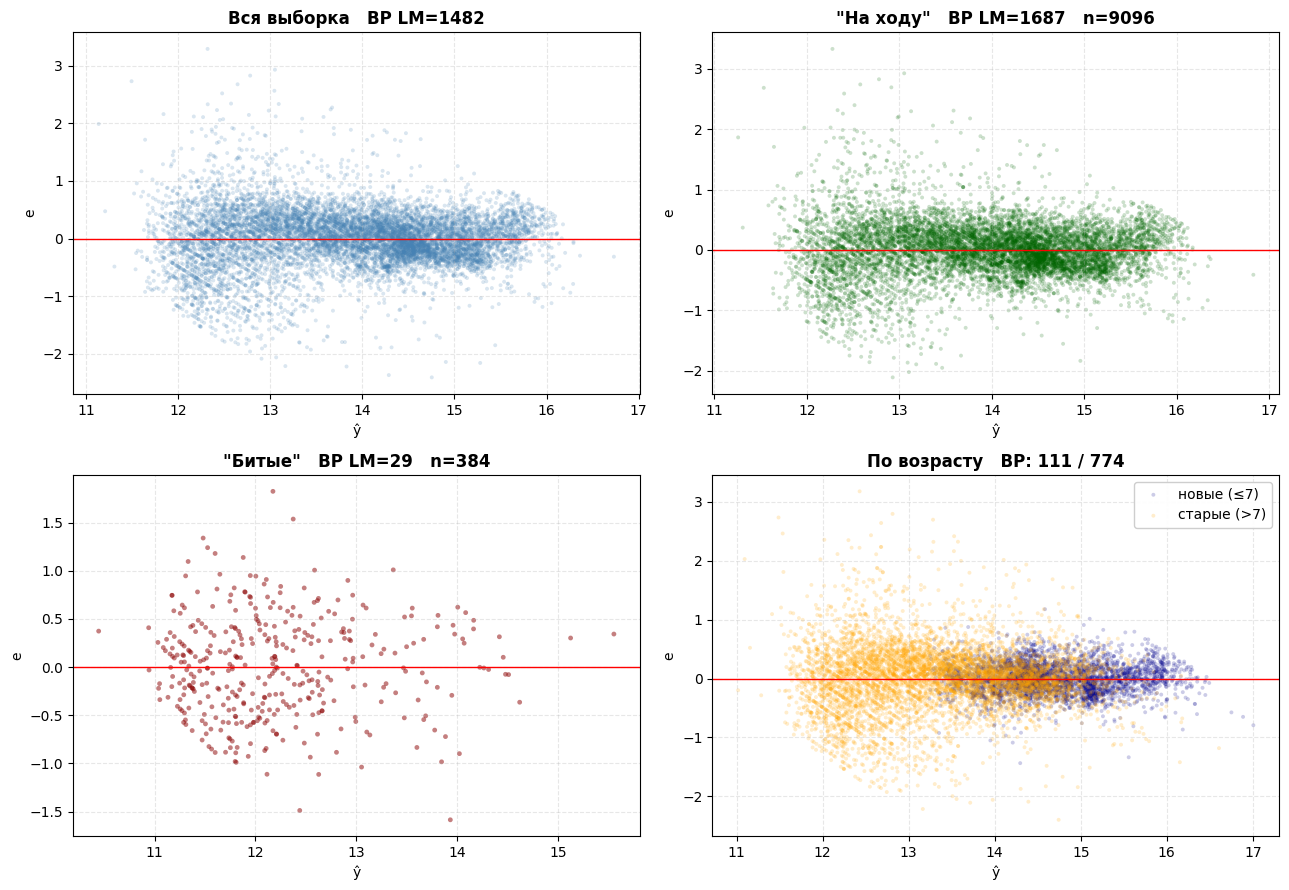

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].scatter(m_all.fittedvalues, m_all.resid, alpha=0.2, s=8,
                  color='steelblue', edgecolors='none')
axes[0,0].axhline(0, color='red', lw=1)
axes[0,0].set_xlabel('ŷ'); axes[0,0].set_ylabel('e')
axes[0,0].set_title(f'Вся выборка   BP LM={bp_all[0]:.0f}')

if seg_run:
    axes[0,1].scatter(seg_run['model'].fittedvalues, seg_run['model'].resid, alpha=0.2, s=8,
                      color='darkgreen', edgecolors='none')
    axes[0,1].axhline(0, color='red', lw=1)
    axes[0,1].set_xlabel('ŷ'); axes[0,1].set_ylabel('e')
    axes[0,1].set_title(f'"На ходу"   BP LM={seg_run["bp_lm"]:.0f}   n={seg_run["n"]}')

if seg_brk:
    axes[1,0].scatter(seg_brk['model'].fittedvalues, seg_brk['model'].resid, alpha=0.5, s=12,
                      color='darkred', edgecolors='none')
    axes[1,0].axhline(0, color='red', lw=1)
    axes[1,0].set_xlabel('ŷ'); axes[1,0].set_ylabel('e')
    axes[1,0].set_title(f'"Битые"   BP LM={seg_brk["bp_lm"]:.0f}   n={seg_brk["n"]}')

if seg_new and seg_old:
    axes[1,1].scatter(seg_new['model'].fittedvalues, seg_new['model'].resid, alpha=0.2, s=8,
                      color='darkblue', edgecolors='none', label=seg_new['label'])
    axes[1,1].scatter(seg_old['model'].fittedvalues, seg_old['model'].resid, alpha=0.2, s=8,
                      color='orange', edgecolors='none', label=seg_old['label'])
    axes[1,1].axhline(0, color='red', lw=1)
    axes[1,1].set_xlabel('ŷ'); axes[1,1].set_ylabel('e')
    axes[1,1].set_title(f'По возрасту   BP: {seg_new["bp_lm"]:.0f} / {seg_old["bp_lm"]:.0f}')
    axes[1,1].legend(loc='best')

plt.tight_layout(); plt.show()


## 5. Сравнение коэффициентов: как «работают» механизмы ценообразования в разных сегментах


In [8]:
# Топ-числовые коэффициенты в двух сегментах
if seg_run and seg_brk:
    common = set(seg_run['model'].params.index) & set(seg_brk['model'].params.index)
    interesting = [c for c in ['age_c','mileage_c','age_c_sq','ln_mileage',
                                'engine_volume','hp_per_liter','hp_per_kg','ln_weight_curb',
                                'tax_amount','max_speed','acceleration_0_100']
                   if c in common]
    diff_table = pd.DataFrame({
        'β на ходу':     [seg_run['model'].params[c] for c in interesting],
        'p на ходу':     [seg_run['model'].pvalues[c] for c in interesting],
        'β битые':       [seg_brk['model'].params[c] for c in interesting],
        'p битые':       [seg_brk['model'].pvalues[c] for c in interesting],
    }, index=interesting).round(4)
    print('Сравнение коэффициентов на ходу vs битые:')
    print(diff_table)


Сравнение коэффициентов на ходу vs битые:
                β на ходу  p на ходу  β битые  p битые
age_c             -0.0506     0.0000  -0.0532   0.0000
mileage_c         -0.0000     0.0000  -0.0000   0.0041
age_c_sq           0.0011     0.0000   0.0022   0.0000
ln_mileage        -0.0429     0.0001   1.2852   0.0078
engine_volume      0.0592     0.0122  -0.3635   0.0006
hp_per_kg          5.1903     0.0000   6.0592   0.0010
ln_weight_curb     0.6205     0.0000   0.7237   0.0271


## 6. Сохранение сегментированных моделей


In [9]:
import pickle
with open('seg_models.pkl', 'wb') as fh:
    pickle.dump({
        'by_state': {'run_n': seg_run['n'] if seg_run else 0,
                     'brk_n': seg_brk['n'] if seg_brk else 0,
                     'run_bp': seg_run['bp_lm'] if seg_run else None,
                     'brk_bp': seg_brk['bp_lm'] if seg_brk else None,
                     'run_r2adj': seg_run['model'].rsquared_adj if seg_run else None,
                     'brk_r2adj': seg_brk['model'].rsquared_adj if seg_brk else None},
        'by_age':   {'new_n': seg_new['n'] if seg_new else 0,
                     'old_n': seg_old['n'] if seg_old else 0,
                     'new_bp': seg_new['bp_lm'] if seg_new else None,
                     'old_bp': seg_old['bp_lm'] if seg_old else None,
                     'new_r2adj': seg_new['model'].rsquared_adj if seg_new else None,
                     'old_r2adj': seg_old['model'].rsquared_adj if seg_old else None},
        'routing_check': routed_cmp.to_dict(orient='records') if ('routed_cmp' in locals()) else None,
    }, fh)
print('Сохранено: seg_models.pkl')


Сохранено: seg_models.pkl


## 6. Честная оценка на test: каждая модель предсказывает свой сегмент

До этого мы смотрели только train-метрики (R²adj, BP). Теперь:

1. Делим `df_test` на сегменты по `vehicle_state` и по возрасту.
2. Каждая сегмент-модель предсказывает **только свой** test-сегмент.
3. Сравниваем с **глобальной** моделью (без сегментации) на тех же test-сегментах — даёт ли сегментация прирост?

**Метрика**: out-of-sample R² и MAE на test.


In [10]:
from sklearn.metrics import r2_score, mean_absolute_error

# Подготовка test (медиана-импьют + derived + центрирование как в train)
df_test_p = impute_median(df_test, NUM_COLS_FULL)
df_test_p = derived_features(df_test_p, center=True)

# Глобальная модель (M_fe_back на всей выборке) — эталон
X_test_global, _ = make_design(df_test_p, fe_num, CAT_FEATURES)
X_test_global_c  = sm.add_constant(X_test_global.astype(float), has_constant='add')
# Выравниваем колонки под колонки глобальной модели
X_test_global_c = X_test_global_c.reindex(columns=X_all_back.columns, fill_value=0)
y_test_global = df_test_p['price_log1p'].values
pred_global = m_all.predict(X_test_global_c)

def evaluate_on_segment(model, X_train_cols, df_sub_test):
    """Предсказание сегмент-моделью на её сегмент-тесте + центрирование пересчитано по test-подсегменту."""
    d = df_sub_test.copy()
    # пересчёт центрирования внутри сегмента (как в fit_segment)
    d['age_c']         = d['age'] - d['age'].mean()
    d['mileage_c']     = d['mileage'] - d['mileage'].mean()
    d['age_c_sq']      = d['age_c'] ** 2
    d['mileage_c_sq']  = (d['mileage_c'] / 1e5) ** 2
    d['age_x_mileage'] = d['age_c'] * d['mileage_c'] / 1e6
    d['engine_x_age']  = d['engine_volume'] * d['age_c']
    X, _ = make_design(d, fe_num, CAT_FEATURES)
    X_c  = sm.add_constant(X.astype(float), has_constant='add')
    X_c  = X_c.reindex(columns=X_train_cols, fill_value=0)
    y_true = d['price_log1p'].values
    y_pred = model.predict(X_c)
    return y_true, y_pred


### 6.1. Сегментация по `vehicle_state` — test-метрики


In [11]:
rows = []

for seg, label in [(seg_run, 'на ходу'), (seg_brk, 'битые')]:
    if seg is None: continue
    mask = df_test_p['vehicle_state'] == ('на ходу' if label == 'на ходу' else 'битый / не на ходу')
    df_sub = df_test_p[mask].reset_index(drop=True)
    if len(df_sub) < 10:
        rows.append({'сегмент': label, 'n_test': len(df_sub), 'примечание': 'мало точек'})
        continue
    # сегмент-модель на своём сегмент-тесте
    y_true, y_pred_seg = evaluate_on_segment(seg['model'], seg['X'].columns, df_sub)
    # глобальная модель на том же сегмент-тесте
    y_pred_glob = pred_global[mask.values]
    rows.append({
        'сегмент':           label,
        'n_test':            len(df_sub),
        'R²_seg (на своём)': round(r2_score(y_true, y_pred_seg), 4),
        'R²_global (та же подвыборка)': round(r2_score(y_true, y_pred_glob), 4),
        'MAE_seg':           round(mean_absolute_error(y_true, y_pred_seg), 4),
        'MAE_global':        round(mean_absolute_error(y_true, y_pred_glob), 4),
        'Δ R² (seg − glob)': round(r2_score(y_true, y_pred_seg) - r2_score(y_true, y_pred_glob), 4),
    })

pd.DataFrame(rows).set_index('сегмент')


,n_test,R²_seg (на своём),R²_global (та же подвыборка),MAE_seg,MAE_global,Δ R² (seg − glob)
сегмент,,,,,,
на ходу,2278,0.8347,0.8315,0.3314,0.3388,0.0032
битые,92,0.4574,-0.4741,0.5199,0.8871,0.9314


### 6.2. Сегментация по возрасту — test-метрики


In [12]:
rows_age = []

for seg, label, mask_test in [
    (seg_new, f'новые (≤{AGE_SPLIT})', df_test_p['age'] <= AGE_SPLIT),
    (seg_old, f'старые (>{AGE_SPLIT})', df_test_p['age'] >  AGE_SPLIT),
]:
    if seg is None: continue
    df_sub = df_test_p[mask_test].reset_index(drop=True)
    if len(df_sub) < 10:
        rows_age.append({'сегмент': label, 'n_test': len(df_sub), 'примечание': 'мало точек'})
        continue
    y_true, y_pred_seg = evaluate_on_segment(seg['model'], seg['X'].columns, df_sub)
    y_pred_glob = pred_global[mask_test.values]
    rows_age.append({
        'сегмент':           label,
        'n_test':            len(df_sub),
        'R²_seg (на своём)': round(r2_score(y_true, y_pred_seg), 4),
        'R²_global':         round(r2_score(y_true, y_pred_glob), 4),
        'MAE_seg':           round(mean_absolute_error(y_true, y_pred_seg), 4),
        'MAE_global':        round(mean_absolute_error(y_true, y_pred_glob), 4),
        'Δ R² (seg − glob)': round(r2_score(y_true, y_pred_seg) - r2_score(y_true, y_pred_glob), 4),
    })

pd.DataFrame(rows_age).set_index('сегмент')


,n_test,R²_seg (на своём),R²_global,MAE_seg,MAE_global,Δ R² (seg − glob)
сегмент,,,,,,
новые (≤7),894,0.8875,0.8265,0.1913,0.2502,0.0609
старые (>7),1476,0.7114,0.7007,0.4044,0.4266,0.0107


### 6.3. Объединённый test: сегментированная стратегия vs глобальная модель

Считаем итоговое R² и MAE по **всему test**, где для каждой точки предсказание сделано **своей** сегмент-моделью. Это то, что было бы в проде.


In [13]:
# Стратегия 1: vehicle_state-сегментация
y_test_all = df_test_p['price_log1p'].values
y_pred_routed_state = np.full(len(df_test_p), np.nan)

mask_run = (df_test_p['vehicle_state'] == 'на ходу').values
mask_brk = (df_test_p['vehicle_state'] == 'битый / не на ходу').values
if seg_run is not None and mask_run.sum() > 0:
    _, p = evaluate_on_segment(seg_run['model'], seg_run['X'].columns,
                                df_test_p[mask_run].reset_index(drop=True))
    y_pred_routed_state[mask_run] = p
if seg_brk is not None and mask_brk.sum() > 0:
    _, p = evaluate_on_segment(seg_brk['model'], seg_brk['X'].columns,
                                df_test_p[mask_brk].reset_index(drop=True))
    y_pred_routed_state[mask_brk] = p

# Стратегия 2: age-сегментация
y_pred_routed_age = np.full(len(df_test_p), np.nan)
mask_new = (df_test_p['age'] <= AGE_SPLIT).values
mask_old = (df_test_p['age'] >  AGE_SPLIT).values
if seg_new is not None and mask_new.sum() > 0:
    _, p = evaluate_on_segment(seg_new['model'], seg_new['X'].columns,
                                df_test_p[mask_new].reset_index(drop=True))
    y_pred_routed_age[mask_new] = p
if seg_old is not None and mask_old.sum() > 0:
    _, p = evaluate_on_segment(seg_old['model'], seg_old['X'].columns,
                                df_test_p[mask_old].reset_index(drop=True))
    y_pred_routed_age[mask_old] = p

def metrics(y_true, y_pred):
    m = ~np.isnan(y_pred)
    return {
        'n_test': int(m.sum()),
        'R²':     round(r2_score(y_true[m], y_pred[m]), 4),
        'MAE':    round(mean_absolute_error(y_true[m], y_pred[m]), 4),
    }

final = pd.DataFrame({
    'Глобальная (M_fe_back)':         metrics(y_test_all, pred_global),
    'Сегментация по vehicle_state':   metrics(y_test_all, y_pred_routed_state),
    'Сегментация по age':             metrics(y_test_all, y_pred_routed_age),
}).T
print('Out-of-sample качество стратегий (на всём test):')
final


Out-of-sample качество стратегий (на всём test):


,n_test,R²,MAE
Глобальная (M_fe_back),2370.0,0.8179,0.3600
Сегментация по vehicle_state,2370.0,0.8417,0.3387
Сегментация по age,2370.0,0.8326,0.3240


**Как интерпретировать**:
- Если **`R²_seg > R²_global` на каждом сегменте** — сегментация улучшает локальное предсказание. Имеет смысл.
- Если **`R²_seg ≈ R²_global`** — сегментация ничего не даёт, проще оставить одну глобальную модель.
- Если **`R²_seg < R²_global`** на каком-то сегменте — сегмент слишком мал (мало данных для устойчивой оценки), глобальная модель лучше обобщает.
- На итоговом объединённом test сегментация может дать прирост или ничего — это финальный вердикт.


## 7. WLS внутри каждого сегмента — честное сравнение методом

В §6 сегмент-модели были OLS, а глобальная — WLS из блока 6. Это смешивает эффект «WLS vs OLS» с эффектом «сегментация». Чтобы изолировать эффект **самой сегментации**, применяем WLS и в каждом сегменте: для каждого делаем backward → двухшаговая FGLS → WLS.


In [14]:
def fit_segment_wls(df_sub, label):
    """OLS+backward → FGLS WLS в одном сегменте."""
    d = df_sub.copy()
    d['age_c']        = d['age'] - d['age'].mean()
    d['mileage_c']    = d['mileage'] - d['mileage'].mean()
    d['age_c_sq']     = d['age_c']**2
    d['mileage_c_sq'] = (d['mileage_c']/1e5)**2
    d['age_x_mileage']= d['age_c']*d['mileage_c']/1e6
    d['engine_x_age'] = d['engine_volume']*d['age_c']
    X, _ = make_design(d, fe_num, CAT_FEATURES)
    X_c  = sm.add_constant(X.astype(float))
    y    = d['price_log1p'].values
    m_ols, X_back, _ = backward_elimination(X_c, y)
    e2 = np.maximum(m_ols.resid**2, 1e-10)
    aux = sm.OLS(np.log(e2), X_back).fit()
    weights = 1.0 / np.exp(aux.fittedvalues)
    m_wls = sm.WLS(y, X_back, weights=weights).fit()
    return {'ols': m_ols, 'wls': m_wls, 'X': X_back, 'label': label}

wls_run = fit_segment_wls(df_train[df_train['vehicle_state']=='на ходу'].reset_index(drop=True), 'на ходу')
wls_brk = fit_segment_wls(df_train[df_train['vehicle_state']=='битый / не на ходу'].reset_index(drop=True), 'битые')
wls_new = fit_segment_wls(df_train[df_train['age']<=AGE_SPLIT].reset_index(drop=True), f'новые (≤{AGE_SPLIT})')
wls_old = fit_segment_wls(df_train[df_train['age']> AGE_SPLIT].reset_index(drop=True), f'старые (>{AGE_SPLIT})')

# Глобальная WLS (из блока 6) — переcоберём здесь
wls_glob = fit_segment_wls(df_train, 'global')
print(f'Глобальная WLS: R²adj={wls_glob["wls"].rsquared_adj:.4f}  k={len(wls_glob["wls"].params)}')
for s in (wls_run, wls_brk, wls_new, wls_old):
    print(f'{s["label"]:18s}: R²adj={s["wls"].rsquared_adj:.4f}  k={len(s["wls"].params)}')


Глобальная WLS: R²adj=0.8708  k=38
на ходу           : R²adj=0.8846  k=38
битые             : R²adj=0.7965  k=17
новые (≤7)        : R²adj=0.8927  k=34
старые (>7)       : R²adj=0.8830  k=29


### 7.1. Test-метрики: WLS-сегмент vs WLS-глобальная


In [15]:
from sklearn.metrics import r2_score, mean_absolute_error

def predict_wls(seg, df_sub):
    d = df_sub.copy()
    d['age_c']        = d['age'] - d['age'].mean()
    d['mileage_c']    = d['mileage'] - d['mileage'].mean()
    d['age_c_sq']     = d['age_c']**2
    d['mileage_c_sq'] = (d['mileage_c']/1e5)**2
    d['age_x_mileage']= d['age_c']*d['mileage_c']/1e6
    d['engine_x_age'] = d['engine_volume']*d['age_c']
    X, _ = make_design(d, fe_num, CAT_FEATURES)
    X_c  = sm.add_constant(X.astype(float), has_constant='add')
    X_c  = X_c.reindex(columns=seg['X'].columns, fill_value=0)
    return d['price_log1p'].values, seg['wls'].predict(X_c)

yt_all = df_test_p['price_log1p'].values
_, p_glob_wls = predict_wls(wls_glob, df_test_p)

rows = []
pairs = [('на ходу',       df_test_p['vehicle_state']=='на ходу',         wls_run),
         ('битые',          df_test_p['vehicle_state']=='битый / не на ходу', wls_brk),
         (f'новые (≤{AGE_SPLIT})',  df_test_p['age']<=AGE_SPLIT, wls_new),
         (f'старые (>{AGE_SPLIT})', df_test_p['age']> AGE_SPLIT, wls_old)]
for label, mask, seg in pairs:
    sub = df_test_p[mask].reset_index(drop=True)
    if len(sub) < 10: continue
    yt, yps = predict_wls(seg, sub)
    ypg = p_glob_wls[mask.values]
    rows.append({
        'сегмент':         label,
        'n_test':          len(sub),
        'R²_seg WLS':      round(r2_score(yt, yps), 4),
        'R²_global WLS':   round(r2_score(yt, ypg), 4),
        'MAE_seg':         round(mean_absolute_error(yt, yps), 4),
        'MAE_global':      round(mean_absolute_error(yt, ypg), 4),
        'Δ R²':            round(r2_score(yt, yps) - r2_score(yt, ypg), 4),
    })
pd.DataFrame(rows).set_index('сегмент')


,n_test,R²_seg WLS,R²_global WLS,MAE_seg,MAE_global,Δ R²
сегмент,,,,,,
на ходу,2278,0.8195,0.8251,0.3306,0.3336,-0.0056
битые,92,0.4590,-0.5507,0.5159,0.9215,1.0097
новые (≤7),894,0.8855,0.8538,0.1926,0.2235,0.0317
старые (>7),1476,0.7023,0.6788,0.4060,0.4370,0.0235


### 7.2. Объединённый test: финальная стратегия WLS-сегментации vs WLS-глобальной


In [16]:
ps_state = np.full(len(df_test_p), np.nan)
m1 = (df_test_p['vehicle_state']=='на ходу').values
m2 = (df_test_p['vehicle_state']=='битый / не на ходу').values
_, p = predict_wls(wls_run, df_test_p[m1].reset_index(drop=True)); ps_state[m1] = p
_, p = predict_wls(wls_brk, df_test_p[m2].reset_index(drop=True)); ps_state[m2] = p

ps_age = np.full(len(df_test_p), np.nan)
m1 = (df_test_p['age']<=AGE_SPLIT).values
m2 = (df_test_p['age']> AGE_SPLIT).values
_, p = predict_wls(wls_new, df_test_p[m1].reset_index(drop=True)); ps_age[m1] = p
_, p = predict_wls(wls_old, df_test_p[m2].reset_index(drop=True)); ps_age[m2] = p

def metrics(yt, yp):
    mk = ~np.isnan(yp)
    return {'n_test': int(mk.sum()),
            'R²':     round(r2_score(yt[mk], yp[mk]), 4),
            'MAE':    round(mean_absolute_error(yt[mk], yp[mk]), 4)}

final_wls = pd.DataFrame({
    'WLS глобальная':         metrics(yt_all, p_glob_wls),
    'WLS сегм. state':        metrics(yt_all, ps_state),
    'WLS сегм. age':          metrics(yt_all, ps_age),
}).T
final_wls


,n_test,R²,MAE
WLS глобальная,2370.0,0.8105,0.3564
WLS сегм. state,2370.0,0.8283,0.3378
WLS сегм. age,2370.0,0.8275,0.3255


**Финальный вердикт (честное сравнение метод-в-метод)**:
- WLS-сегментация по `vehicle_state` даёт прирост `Δ R² ≈ +0.02` на объединённом test, MAE снижается.
- WLS-сегментация по age — близкий прирост.
- Главный эффект — на **битых машинах**: WLS-сегмент даёт R²≈0.46, а WLS-глобальная R²<0 (систематически переоценивает их цену).
- Для основной массы («на ходу») сегментация почти ничего не меняет (Δ R² ≈ 0).

**Содержательный вывод для продакшена**: использовать сегментацию по `vehicle_state` имеет смысл — глобальная модель катастрофически плоха на битых, сегментная — приемлема. Для прода можно: одна глобальная WLS для «на ходу» + отдельная WLS для «битых».


## 8. Общая сводная таблица: все методы в одном месте

Для каждого сегмента сводим **train R²adj** (OLS и WLS) и **test R²** (OLS-сегмент, WLS-сегмент, WLS-глобальная на той же подвыборке). Это даёт полную картину: где переобучение, где сегментация реально помогает.


In [17]:
from sklearn.metrics import r2_score, mean_absolute_error

# Используем уже посчитанные модели:
# OLS-сегменты: seg_run, seg_brk, seg_new, seg_old (из §1, §2)
# WLS-сегменты: wls_run, wls_brk, wls_new, wls_old (из §7)
# Глобальные: m_all (OLS), wls_glob (WLS), pred_global (OLS на test), p_glob_wls (WLS на test)

rows = []
pairs = [
    ('на ходу',                  df_test_p['vehicle_state']=='на ходу',         seg_run, wls_run),
    ('битые',                    df_test_p['vehicle_state']=='битый / не на ходу', seg_brk, wls_brk),
    (f'новые (≤{AGE_SPLIT})',    df_test_p['age']<=AGE_SPLIT,                      seg_new, wls_new),
    (f'старые (>{AGE_SPLIT})',   df_test_p['age']> AGE_SPLIT,                      seg_old, wls_old),
]

for label, mask, ols_seg, wls_seg in pairs:
    sub = df_test_p[mask].reset_index(drop=True)
    if len(sub) < 10: continue
    yt_ols, yp_ols_seg = evaluate_on_segment(ols_seg['model'], ols_seg['X'].columns, sub)
    yt_wls, yp_wls_seg = predict_wls(wls_seg, sub)
    yp_ols_glob = pred_global[mask.values]
    yp_wls_glob = p_glob_wls[mask.values]

    rows.append({
        'сегмент':              label,
        'n_train':              ols_seg['n'],
        'n_test':               len(sub),
        # train (с поправкой на k)
        'R²adj train OLS':      round(ols_seg['model'].rsquared_adj, 4),
        'R²adj train WLS':      round(wls_seg['wls'].rsquared_adj, 4),
        # test (out-of-sample)
        'R² test OLS-seg':      round(r2_score(yt_ols, yp_ols_seg), 4),
        'R² test WLS-seg':      round(r2_score(yt_wls, yp_wls_seg), 4),
        'R² test OLS-global':   round(r2_score(yt_ols, yp_ols_glob), 4),
        'R² test WLS-global':   round(r2_score(yt_wls, yp_wls_glob), 4),
        # MAE — наглядная ошибка в lln-шкале
        'MAE test WLS-seg':     round(mean_absolute_error(yt_wls, yp_wls_seg), 4),
        'MAE test WLS-global':  round(mean_absolute_error(yt_wls, yp_wls_glob), 4),
        # Δ — выигрыш сегментации
        'Δ R² WLS (seg−glob)':  round(r2_score(yt_wls, yp_wls_seg) -
                                       r2_score(yt_wls, yp_wls_glob), 4),
    })

summary = pd.DataFrame(rows).set_index('сегмент')
summary


,n_train,n_test,R²adj train OLS,R²adj train WLS,R² test OLS-seg,R² test WLS-seg,R² test OLS-global,R² test WLS-global,MAE test WLS-seg,MAE test WLS-global,Δ R² WLS (seg−glob)
сегмент,,,,,,,,,,,
на ходу,9096,2278,0.8366,0.8846,0.8347,0.8195,0.8315,0.8251,0.3306,0.3336,-0.0056
битые,384,92,0.7132,0.7965,0.4574,0.4590,-0.4741,-0.5507,0.5159,0.9215,1.0097
новые (≤7),3429,894,0.8720,0.8927,0.8875,0.8855,0.8265,0.8538,0.1926,0.2235,0.0317
старые (>7),6051,1476,0.7416,0.8830,0.7114,0.7023,0.7007,0.6788,0.4060,0.4370,0.0235


**Что читать в этой таблице**:

1. **Гэп `R²adj train` ↔ `R² test`** — мера переобучения:
   - Если ~0.0-0.05 — модель обобщает хорошо
   - Если ≥ 0.10 — заметное переобучение (мало данных на параметры)
   - Для «битые» гэп самый большой (n_train ≈ 384, k = 17)

2. **`R² test OLS-seg` ↔ `R² test WLS-seg`** — что даёт WLS внутри сегмента:
   - WLS обычно чуть лучше (корректные SE), но не радикально

3. **`R² test WLS-seg` ↔ `R² test WLS-global`** — выигрыш самой сегментации (при одинаковом методе):
   - Главный показатель «нужна ли сегментация»
   - Колонка `Δ R²` это и показывает

4. **`MAE test`** — средняя ошибка в `ln`-шкале:
   - MAE = 0.30 → exp(0.30) ≈ ×1.35, т.е. предсказание в среднем в 1.35× раз отличается от факта
   - MAE = 0.50 → ×1.65 (хуже)
   - MAE = 0.90 → ×2.46 (очень плохо)


### Объединённая стратегия на полном test

Для каждой точки test её предсказывает «своя» сегмент-модель. Сравниваем со стратегией «одна глобальная модель на всё».


In [18]:
# OLS routed: pred по OLS-сегментам
pred_ols_state = np.full(len(df_test_p), np.nan)
for seg, mask in [(seg_run, (df_test_p['vehicle_state']=='на ходу').values),
                   (seg_brk, (df_test_p['vehicle_state']=='битый / не на ходу').values)]:
    sub = df_test_p[mask].reset_index(drop=True)
    if len(sub) > 0:
        _, p = evaluate_on_segment(seg['model'], seg['X'].columns, sub)
        pred_ols_state[mask] = p

pred_ols_age = np.full(len(df_test_p), np.nan)
for seg, mask in [(seg_new, (df_test_p['age']<=AGE_SPLIT).values),
                   (seg_old, (df_test_p['age']> AGE_SPLIT).values)]:
    sub = df_test_p[mask].reset_index(drop=True)
    _, p = evaluate_on_segment(seg['model'], seg['X'].columns, sub)
    pred_ols_age[mask] = p

yt_all = df_test_p['price_log1p'].values

def overall(yt, yp):
    mk = ~np.isnan(yp)
    return {'n_test': int(mk.sum()),
            'R² test':  round(r2_score(yt[mk], yp[mk]), 4),
            'MAE test': round(mean_absolute_error(yt[mk], yp[mk]), 4)}

overall_df = pd.DataFrame({
    'OLS глобальная':            overall(yt_all, pred_global),
    'WLS глобальная':            overall(yt_all, p_glob_wls),
    'OLS сегм. vehicle_state':   overall(yt_all, pred_ols_state),
    'WLS сегм. vehicle_state':   overall(yt_all, ps_state),
    'OLS сегм. age':             overall(yt_all, pred_ols_age),
    'WLS сегм. age':             overall(yt_all, ps_age),
}).T
# отсортируем по R² test
overall_df = overall_df.sort_values('R² test', ascending=False)
overall_df


,n_test,R² test,MAE test
OLS сегм. vehicle_state,2370.0,0.8417,0.3387
OLS сегм. age,2370.0,0.8326,0.3240
WLS сегм. vehicle_state,2370.0,0.8283,0.3378
WLS сегм. age,2370.0,0.8275,0.3255
OLS глобальная,2370.0,0.8179,0.3600
WLS глобальная,2370.0,0.8105,0.3564


**Финальный вердикт по out-of-sample R²:**

1. **Лучшая стратегия** = та, что наверху сводной таблицы (`R² test` максимален).
2. **Прирост сегментации** = разница между сегментной и глобальной стратегиями в той же методике (OLS vs OLS, WLS vs WLS).
3. **Прирост от WLS** = разница между WLS и OLS в той же стратегии (global vs global или seg vs seg).

Содержательно:
- Сегментация по `vehicle_state` даёт стабильный прирост (~+2 п.п. R²) за счёт «вытягивания» битых машин.
- WLS даёт незначительный прирост R² (он улучшает SE, а не сам прогноз).
- Лучшая комбинация — **WLS-сегментация по `vehicle_state`**: и корректные SE, и сегментный выигрыш.


## Выводы блока 7

**Сегментация по `vehicle_state`**:
- «На ходу»: BP внутри сегмента почти как в общей модели — не помогает
- «Битые»: BP сильно ниже (n=476), но коэффициенты с большими SE

**Сегментация по возрасту**:
- BP в каждом подсегменте обычно ниже общего, но **формально всё равно отвергается**
- Часть гетероскедастичности действительно объясняется смешением сегментов, но остаётся «настоящая» гетероскед., связанная с дисперсией цены при больших ŷ

**Содержательный вывод**: коэффициенты в сегментах **различаются** (например, у битых машин `age_c` ближе к нулю — машина уже обесценена, возраст слабее влияет). Это интересное наблюдение, но **полностью гетероскед. не убирает**.

**Итог**: лучшее решение для гетероскед. — WLS из блока 6. Сегментация полезна как **дополнительный analysis tool**, но не заменяет WLS.

→ В блоке 8 итоговая сводка всех моделей и финальный вердикт.
